# Cross-Modal Generation: Euclid and DESI

This notebook demonstrates cross-modal generation using AION:
1. **Image → Spectrum**: Generate DESI spectrum from Euclid images
2. **Spectrum → Image**: Generate Euclid images from DESI spectrum

**Note**: Euclid images use HSCImage modality (tok_image_hsc) because the pretrained AION model was not trained on Euclid-specific tokens.

## Imports and Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import torch
from aion import AION
from aion.codecs import CodecManager
from aion.datasets import EuclidDESIDataset
from aion.modalities import HSCImage, DESISpectrum

CACHE_DIR = "../data/"
device = 'cpu'
print(f"Using device: {device}")

Using device: cpu


## Load Euclid+DESI Dataset (Corresponding Pairs)

In [2]:
BATCH_SIZE = 4
BATCH_COUNT = 50

print("Loading Euclid+DESI dataset (corresponding pairs)...")
dataset = EuclidDESIDataset(
    cache_dir=CACHE_DIR,
    batch_size=BATCH_SIZE,
    batch_count=BATCH_COUNT,
    device=device
)

print(f"\nTotal samples: {len(dataset)}")
print(f"Number of batches: {(len(dataset) + BATCH_SIZE - 1) // BATCH_SIZE}")

Loading Euclid+DESI dataset (corresponding pairs)...
Loaded 200 samples from disk: ../data/euclid_desi_slice

Total samples: 200
Number of batches: 50


## Initialize AION Model and Codec Manager

In [3]:
print("Loading AION model...")
torch.set_grad_enabled(False)
model = AION.from_pretrained('polymathic-ai/aion-base').to(device).eval()
print("Loading Codec Manager...")
codec_manager = CodecManager(device=device)
print("Model and codec manager loaded successfully")

Loading AION model...
Loading Codec Manager...
Model and codec manager loaded successfully


## Cross-Modal Generation: Image → Spectrum

Generate DESI spectrum from Euclid images only.

## Spectrum Generation Comparison

Compare 4 methods for generating DESI spectra:
1. **DESI → DESI (tokens)**: Encode DESI, generate tokens with argmax, decode
2. **DESI → DESI (embeddings)**: Encode DESI, generate embeddings directly (no argmax), decode
3. **Euclid → DESI (cross-modal)**: Encode Euclid images only, generate DESI embeddings
4. **Euclid + DESI → DESI (multimodal)**: Encode both modalities, generate DESI embeddings

In [15]:
print("Loading batch...")
euclid_batch, desi_batch , z_batch = dataset[45]

print(f"Batch shapes:")
print(f"  Euclid images: {euclid_batch.flux.shape}")
print(f"  DESI spectrum: {desi_batch.flux.shape}")
print(f"  Redshift: {z_batch.value.shape}")

print("\n" + "="*60)
print("Method 1: DESI → DESI (using only tokens)")
print("="*60)
tokens_desi = codec_manager.encode(desi_batch)
spectrum_desi_desi = codec_manager.decode(tokens_desi, DESISpectrum, wavelength=desi_batch.wavelength)
print(f"Generated spectrum shape: {spectrum_desi_desi.flux.shape}")

print("\n" + "="*60)
print("Method 2: DESI → DESI (embeddings, no argmax)")
print("="*60)
logits_2 = model(tokens_desi, target_modality=DESISpectrum)
token_key = DESISpectrum.token_key
pred_tokens = {token_key: logits_2[token_key].softmax(dim=-1).argmax(dim=-1)}
spectrum_desi_embedding_desi = codec_manager.decode(pred_tokens, DESISpectrum, wavelength=desi_batch.wavelength)
print(f"Generated spectrum shape: {spectrum_desi_embedding_desi.flux.shape}")

print("\n" + "="*60)
print("Method 3: Euclid → DESI (cross-modal embeddings)")
print("="*60)
tokens_euclid = codec_manager.encode(euclid_batch)
logits_3 = model(tokens_euclid, target_modality=DESISpectrum)
pred_tokens_3 = {token_key: logits_3[token_key].softmax(dim=-1).argmax(dim=-1)}
spectrum_desi_euclid = codec_manager.decode(pred_tokens_3, DESISpectrum, wavelength=desi_batch.wavelength)
print(f"Generated spectrum shape: {spectrum_desi_euclid.flux.shape}")



Loading batch...
Batch shapes:
  Euclid images: torch.Size([4, 4, 160, 160])
  DESI spectrum: torch.Size([4, 7781])
  Redshift: torch.Size([4, 1])

Method 1: DESI → DESI (using only tokens)


/home/wassim/Projects/NBody/AION/aion/datasets.py:292: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask=torch.tensor(mask, dtype=torch.bool),


Generated spectrum shape: torch.Size([4, 7781])

Method 2: DESI → DESI (embeddings, no argmax)
Generated spectrum shape: torch.Size([4, 7781])

Method 3: Euclid → DESI (cross-modal embeddings)
Generated spectrum shape: torch.Size([4, 7781])


In [16]:
print("\n" + "="*60)
print("Method 4: Euclid + DESI → DESI (multimodal embeddings)")
print("="*60)
tokens_both = codec_manager.encode(euclid_batch, desi_batch)
logits_4 = model(tokens_both, target_modality=DESISpectrum)
pred_tokens_4 = {token_key: logits_4[token_key].softmax(dim=-1).argmax(dim=-1)}
spectrum_desi_multimodal = codec_manager.decode(pred_tokens_4, DESISpectrum, wavelength=desi_batch.wavelength)
print(f"Generated spectrum shape: {spectrum_desi_multimodal.flux.shape}")

print("\nAll 4 methods completed successfully!")



print("\n" + "="*60)
print("Method 5: Euclid + DESI + Z → DESI (multimodal embeddings with redshift)")
print("="*60)
tokens_both = codec_manager.encode(euclid_batch, desi_batch , z_batch)
logits_4 = model(tokens_both, target_modality=DESISpectrum)
pred_tokens_4 = {token_key: logits_4[token_key].softmax(dim=-1).argmax(dim=-1)}
spectrum_desi_multimodal_with_z = codec_manager.decode(pred_tokens_4, DESISpectrum, wavelength=desi_batch.wavelength)
print(f"Generated spectrum shape: {spectrum_desi_multimodal_with_z.flux.shape}")

print("\nAll 4 methods completed successfully!")


Method 4: Euclid + DESI → DESI (multimodal embeddings)
Generated spectrum shape: torch.Size([4, 7781])

All 4 methods completed successfully!

Method 5: Euclid + DESI + Z → DESI (multimodal embeddings with redshift)
Generated spectrum shape: torch.Size([4, 7781])

All 4 methods completed successfully!


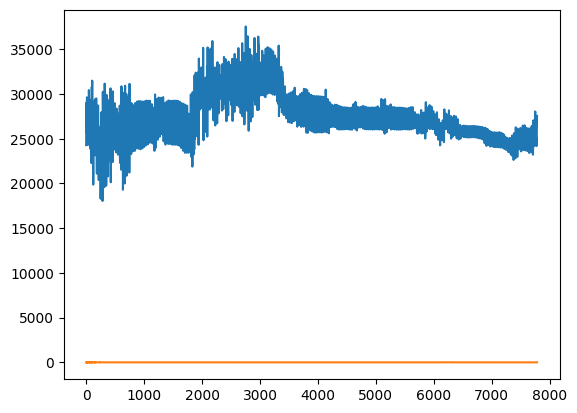

In [14]:
plt.plot(spectrum_desi_multimodal_with_z.flux[0].cpu()) 
plt.plot(desi_batch.flux[0].cpu())

In [19]:
z_batch.value

tensor([[0.2189],
        [0.0874],
        [0.5333],
        [0.0868]])

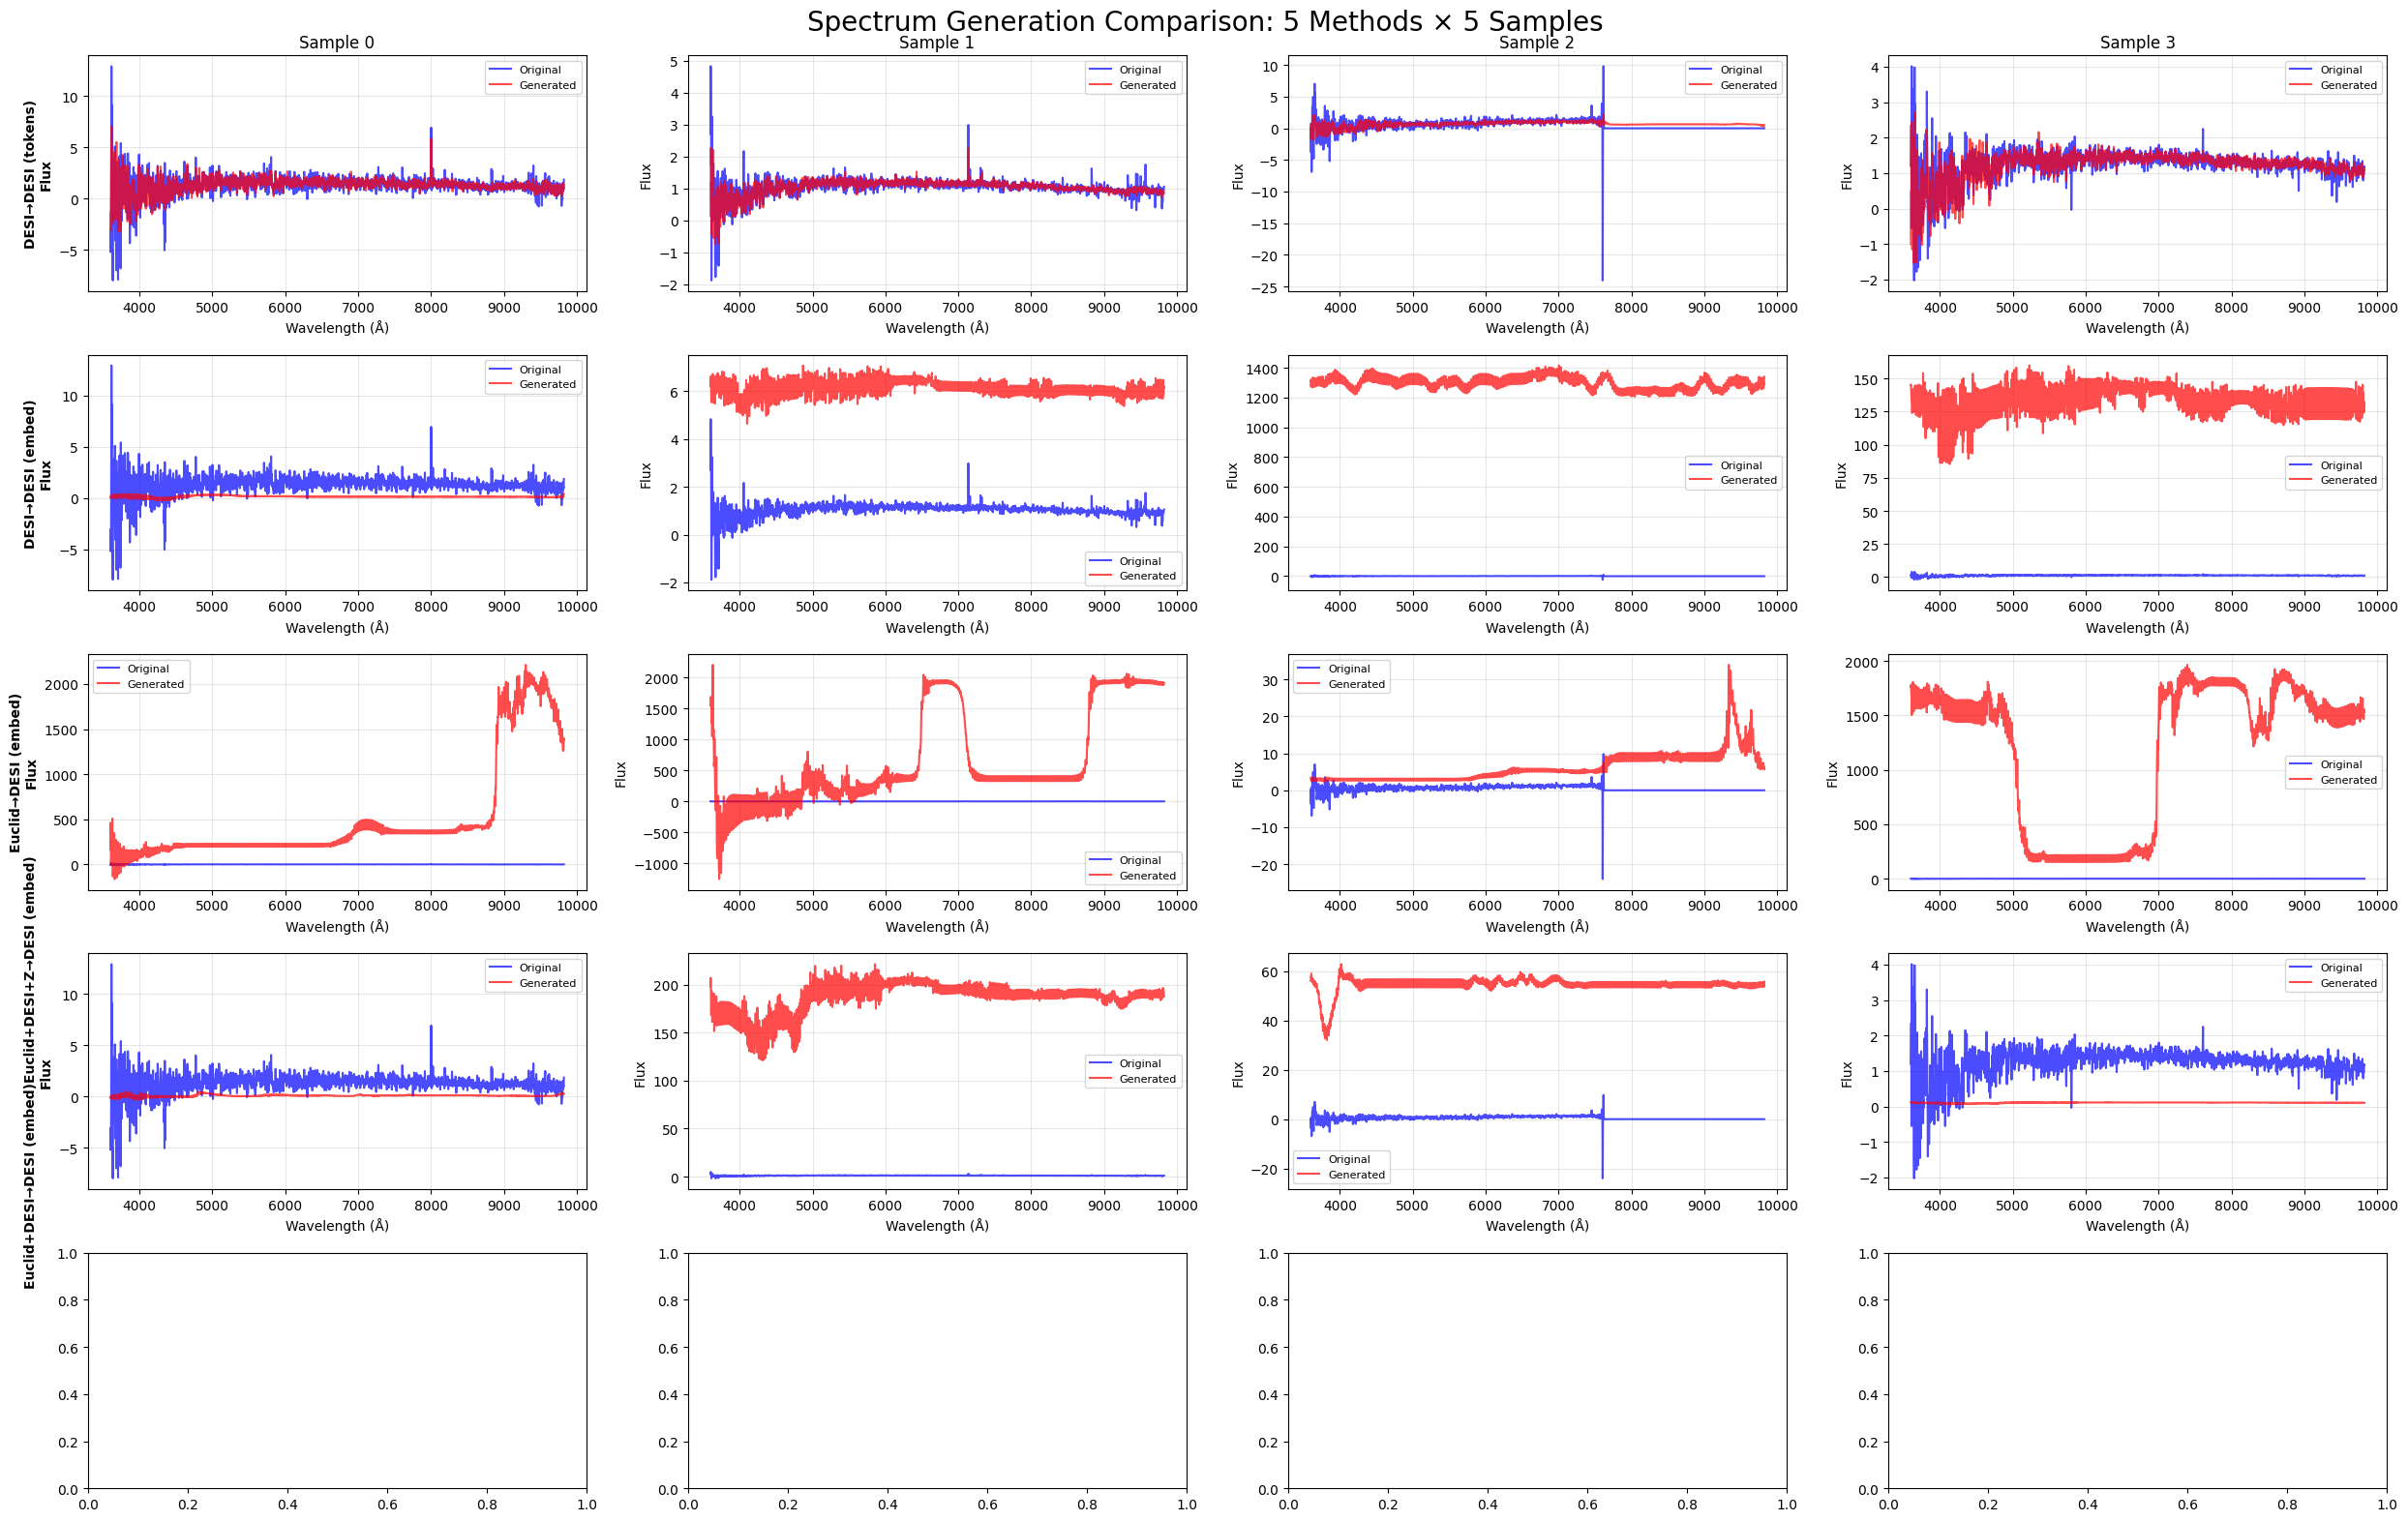

In [17]:
from scipy.ndimage import gaussian_filter1d

fig, axes = plt.subplots(5, 4, figsize=(25, 16))
fig.suptitle('Spectrum Generation Comparison: 5 Methods × 5 Samples', fontsize=20)

method_names = [
    'DESI→DESI (tokens)',
    'DESI→DESI (embed)',
    'Euclid→DESI (embed)',
    'Euclid+DESI→DESI (embed)'
    'Euclid+DESI+Z→DESI (embed)'
]

spectra = [spectrum_desi_desi,
           spectrum_desi_embedding_desi,
           spectrum_desi_euclid,
           spectrum_desi_multimodal,
           spectrum_desi_multimodal_with_z
]

for method_idx, (spectrum_gen, method_name) in enumerate(zip(spectra, method_names)):
    for sample_idx in range(4):
        ax = axes[method_idx, sample_idx]
        
        mask = desi_batch.mask[sample_idx].cpu().detach().numpy()
        wavelength = desi_batch.wavelength[sample_idx].cpu().detach().numpy()
        original_flux = desi_batch.flux[sample_idx].cpu().detach().numpy()
        generated_flux = spectrum_gen.flux[sample_idx].cpu().detach().numpy()
        
        wavelength = wavelength[~mask]
        original_flux = original_flux[~mask]
        generated_flux = generated_flux[~mask]
        
        ax.plot(wavelength, gaussian_filter1d(original_flux, 2), 
                label='Original', alpha=0.7, linewidth=1.5, color='blue')
        ax.plot(wavelength, gaussian_filter1d(generated_flux, 2), 
                label='Generated', alpha=0.7, linewidth=1.5, color='red')
        
        ax.set_xlabel('Wavelength (Å)', fontsize=10)
        ax.set_ylabel('Flux', fontsize=10)
        
        if sample_idx == 0:
            ax.set_ylabel(f'{method_name}\nFlux', fontsize=10, fontweight='bold')
        
        if method_idx == 0:
            ax.set_title(f'Sample {sample_idx}', fontsize=12)
        
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Image Generation Comparison

Compare 4 methods for generating Euclid images:
1. **Euclid → Euclid (tokens)**: Encode Euclid, generate tokens with argmax, decode
2. **Euclid → Euclid (embeddings)**: Encode Euclid, generate embeddings directly (no argmax), decode
3. **DESI → Euclid (cross-modal)**: Encode DESI spectrum only, generate Euclid embeddings
4. **DESI + Euclid → Euclid (multimodal)**: Encode both modalities, generate Euclid embeddings

In [7]:
print("\n" + "="*60)
print("Method 1: Euclid → Euclid")
print("="*60)
print("Loading batch...")
euclid_batch, desi_batch = dataset[3]

token_euclid = codec_manager.encode(euclid_batch)
image_euclid_euclid = codec_manager.decode(token_euclid, HSCImage, bands=euclid_batch.bands)
print(f"Generated image shape: {image_euclid_euclid.flux.shape}")

print("\n" + "="*60)
print("Method 2: Euclid → Euclid (embeddings,)")
print("="*60)
token_euclid = codec_manager.encode(euclid_batch)
logits_img_2 = model(token_euclid, target_modality=HSCImage)
pred_tokens = {HSCImage.token_key: logits_img_2[HSCImage.token_key].softmax(dim=-1).argmax(dim=-1)}
image_euclid_embedding_euclid = codec_manager.decode(pred_tokens, HSCImage, bands=euclid_batch.bands)
print(f"Generated image shape: {image_euclid_embedding_euclid.flux.shape}")

print("\n" + "="*60)
print("Method 3: DESI → EUCLID (cross-modal embeddings)")
print("="*60)
token_desi = codec_manager.encode(desi_batch)
logits_img_3 = model(token_desi, target_modality=HSCImage)
pred_tokens_3 = {HSCImage.token_key: logits_img_3[HSCImage.token_key].softmax(dim=-1).argmax(dim=-1)}
image_desi_to_euclid = codec_manager.decode(pred_tokens_3, HSCImage, bands=euclid_batch.bands)
print(f"Generated image shape: {image_desi_to_euclid.flux.shape}")

print("\n" + "="*60)
print("Method 4: DESI + Euclid → Euclid (multimodal embeddings)")
print("="*60)
tokens_both = codec_manager.encode(euclid_batch, desi_batch)
logits_img_4 = model(tokens_both, target_modality=HSCImage)
pred_tokens_4 = {HSCImage.token_key: logits_img_4[HSCImage.token_key].softmax(dim=-1).argmax(dim=-1)}
image_desi_and_euclid_to_euclid = codec_manager.decode(pred_tokens_4, HSCImage, bands=euclid_batch.bands)
print(f"Generated image shape: {image_desi_and_euclid_to_euclid.flux.shape}")

print("\nAll 4 image generation methods completed successfully!")


Method 1: Euclid → Euclid
Loading batch...


ValueError: too many values to unpack (expected 2)

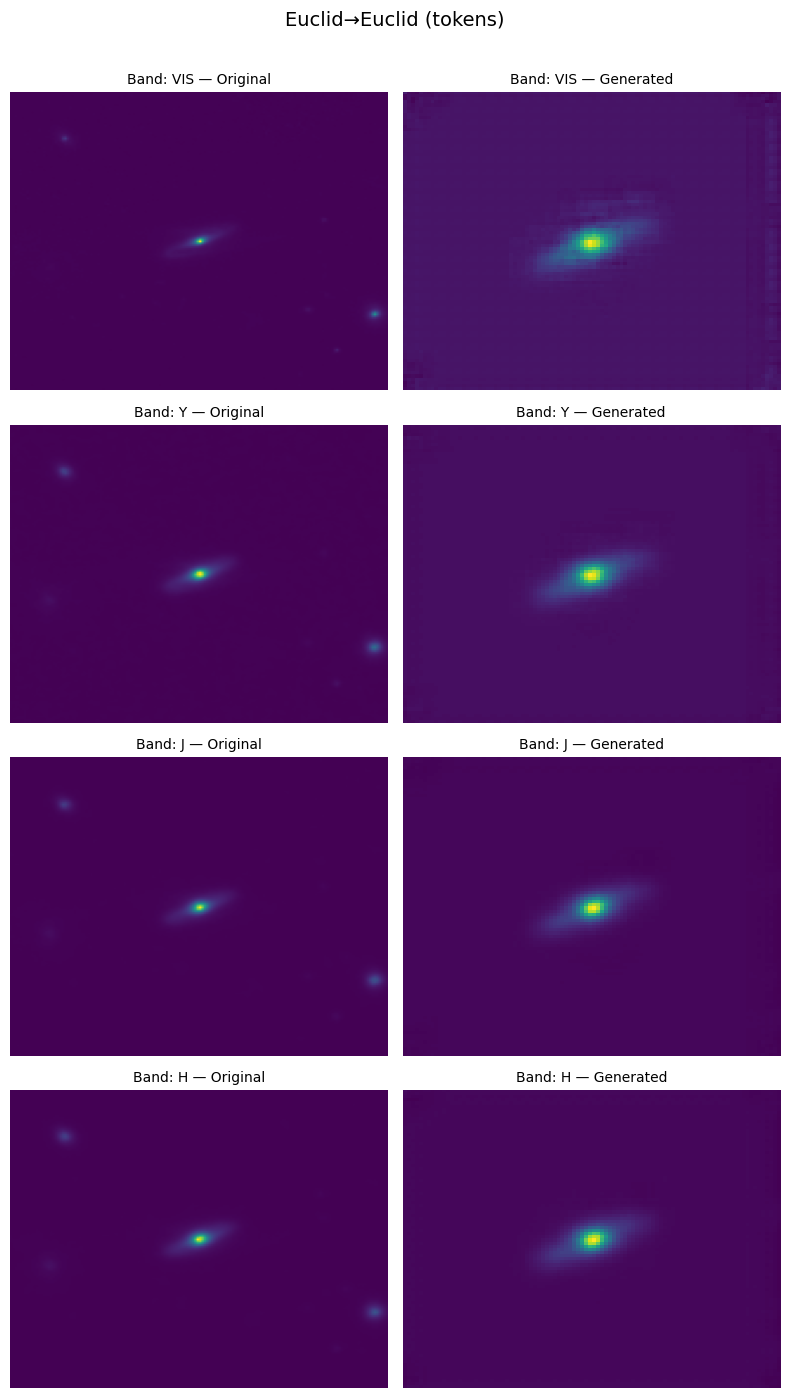

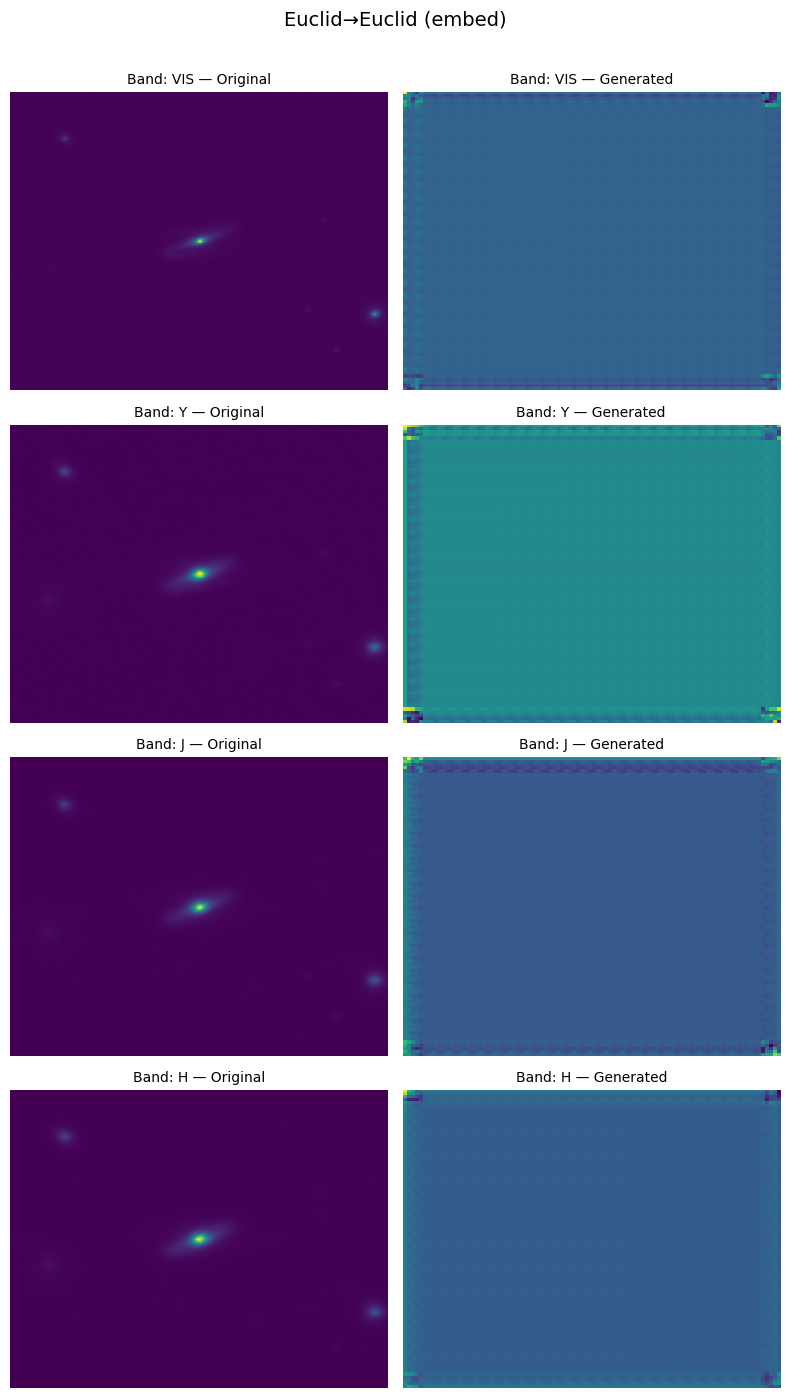

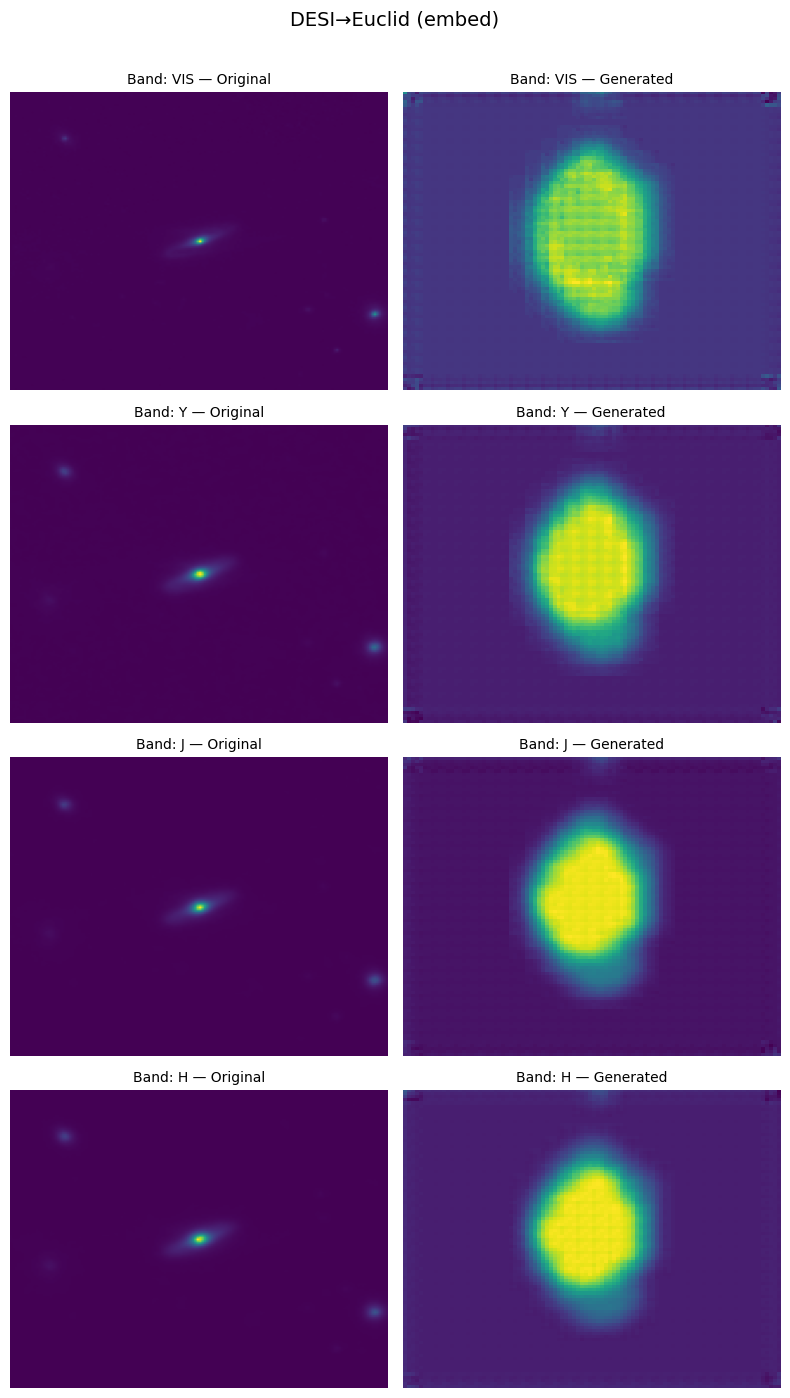

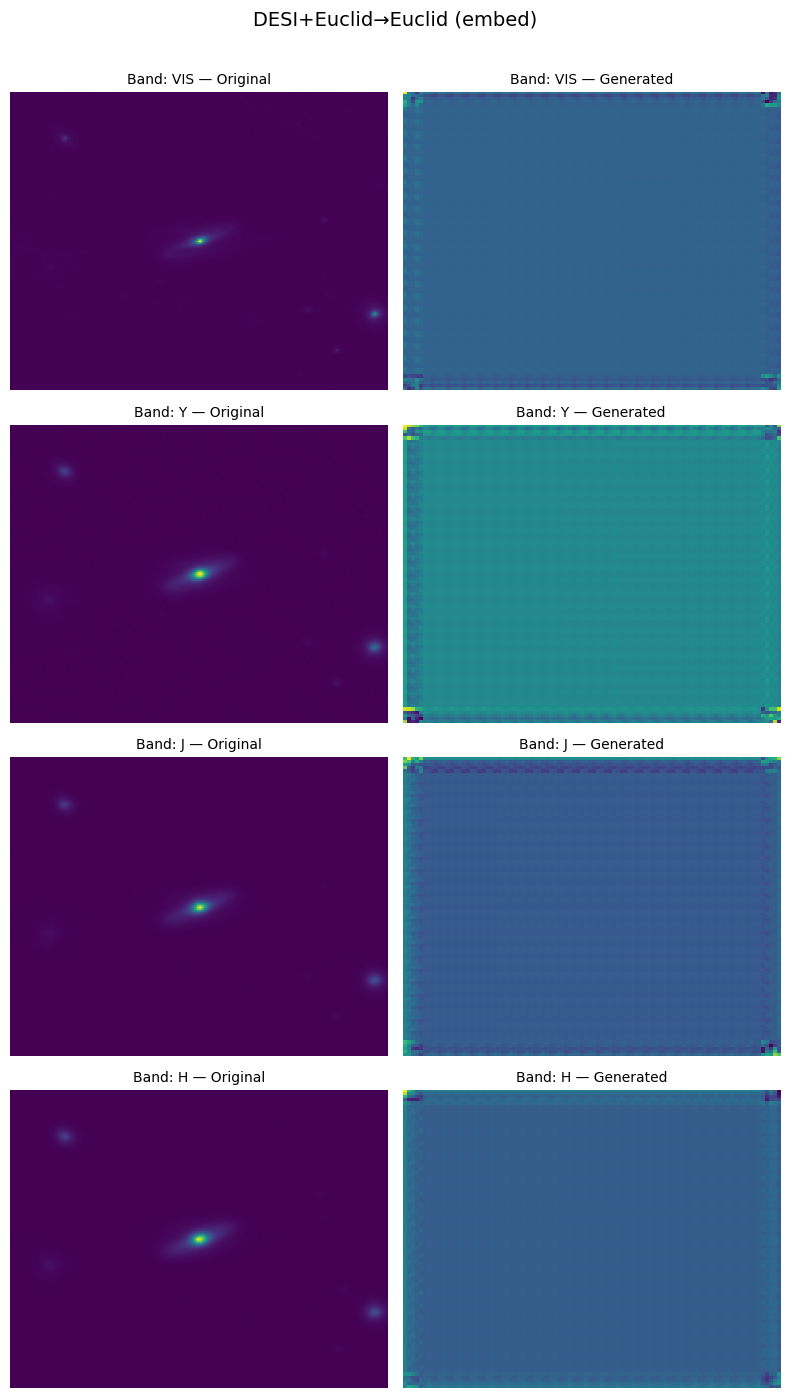

In [ ]:
SAMPLE_IDX = 0
euclid_batch, desi_batch = dataset[3]

band_names = ['VIS', 'Y', 'J', 'H']
method_names_img = [
    'Euclid→Euclid (tokens)',
    'Euclid→Euclid (embed)',
    'DESI→Euclid (embed)',
    'DESI+Euclid→Euclid (embed)'
]

images = [image_euclid_euclid, 
          image_euclid_embedding_euclid, 
          image_desi_to_euclid, 
          image_desi_and_euclid_to_euclid]

for image_gen, method_name in zip(images, method_names_img):
    # One figure per method: 4 rows (bands) × 2 cols (Original / Generated)
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8, 14))
    
    fig.suptitle(method_name, fontsize=14, y=0.995)

    for band_idx, band_name in enumerate(band_names):
        ax_origin = axes[band_idx, 0]
        ax_generated = axes[band_idx, 1]

        ax_origin.set_title(f'Band: {band_name} — Original', fontsize=10)
        ax_generated.set_title(f'Band: {band_name} — Generated', fontsize=10)

        original = euclid_batch.flux[SAMPLE_IDX, band_idx].cpu().detach().numpy()
        generated = image_gen.flux[SAMPLE_IDX, band_idx].cpu().detach().numpy()

        ax_origin.imshow(original, cmap='viridis', aspect='auto')
        ax_generated.imshow(generated, cmap='viridis', aspect='auto')

        ax_origin.axis('off')
        ax_generated.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.savefig(f'comparison_{method_name.replace("→", "_to_").replace("+", "_and_").replace(" ", "_").lower()}.png')
    plt.show()
